In [1]:
import os

PROJECT_DIR = r"C:\Users\skjha\Documents\Codex\2026-06-01\2-road-damage-detection-for-smart"
os.chdir(PROJECT_DIR)

print("Current directory:", os.getcwd())

Current directory: C:\Users\skjha\Documents\Codex\2026-06-01\2-road-damage-detection-for-smart


In [4]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [5]:
MODEL_PATH = Path("ml/models/road_damage_resnet50.keras")
LABELS_PATH = Path("ml/models/road_damage_resnet50_labels.json")
TEST_DIR = Path("data/processed/test")

In [6]:
model = tf.keras.models.load_model(MODEL_PATH)

In [8]:
class_names = json.loads(LABELS_PATH.read_text(encoding="utf-8"))

In [10]:
print("Loaded model:", MODEL_PATH)
print("Classes:", class_names)

Loaded model: ml\models\road_damage_resnet50.keras
Classes: ['crack', 'manhole', 'pothole']


In [12]:
sample_class = random.choice(class_names)
sample_image_path = random.choice(list((TEST_DIR / sample_class).glob("*.jpg")))

In [14]:
image = tf.keras.utils.load_img(sample_image_path, target_size=(224, 224))
image_array = tf.keras.utils.img_to_array(image)
batch = np.expand_dims(image_array, axis=0)

In [15]:
probabilities = model.predict(batch, verbose=0)[0]
predicted_index = int(np.argmax(probabilities))

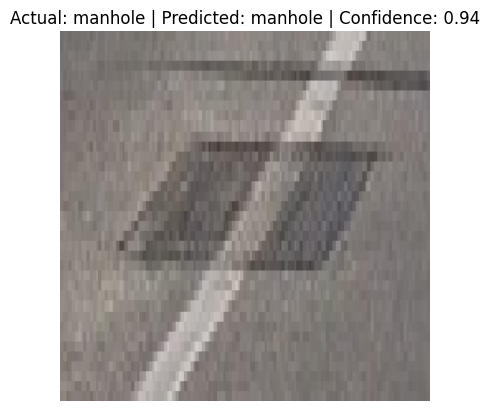

In [16]:
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Actual: {sample_class} | Predicted: {class_names[predicted_index]} | Confidence: {probabilities[predicted_index]:.2f}"
)
plt.show()

In [17]:
for class_name, probability in zip(class_names, probabilities):
    print(f"{class_name}: {probability:.4f}")

crack: 0.0049
manhole: 0.9381
pothole: 0.0571
